In [ ]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
    -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__.split('+')[0])")+cu118.html


Looking in links: https://data.pyg.org/whl/torch-2.9.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
from collections import OrderedDict
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')

# define datatype
if torch.cuda.is_available():
    dtype = torch.cuda.FloatTensor
    dtype_long = torch.cuda.LongTensor
else:
    dtype = torch.FloatTensor
    dtype_long = torch.LongTensor

# model formulation
class GNN_LMSC_cell(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, units:int, gcn_type: str,
                    batch_size: int,  # this entry is unnecessary, kept only for backward compatibility
                    width=125, depth=4,):
            super(GNN_LMSC_cell, self).__init__()

            self.in_channels = in_channels
            self.out_channels = out_channels
            self.units = units
            self.gcn_type = gcn_type
            self.batch_size = batch_size  # not needed
            self.depth = depth

            start_dim = units + in_channels
            inside_dim = start_dim
            self.qb =  Quadratic_block(inside_dim, width, depth)

            if gcn_type == 'GCNConv':
                self.gconv1 = GCN_block(inside_dim, inside_dim, layer = 1)
                self.gconv2 = GCN_block(inside_dim, inside_dim, layer = 1)

            if self.depth>0:
                inside_dim = width
            else:
                inside_dim = in_channels

            self.fc_alpha = nn.Linear(inside_dim,units)
            self.fc_beta = nn.Linear(inside_dim,units)

            for m in self.modules():
                if isinstance(m, nn.Linear):
                    torch.nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        m.bias.data.fill_(0)
                    # m.bias.data.fill_(0)

    def forward(
        self,
        X: torch.FloatTensor,
        edge_index: torch.LongTensor,
        edge_weight: torch.FloatTensor = None,
        H: torch.FloatTensor = None,
        ) -> torch.FloatTensor:

        # Input strain increment X-> [batch, seq_len, in_dim]
        # Hidden state H -> [batch, node_number, hidden_dim]

        h_t = H

        strain_norm = torch.norm(X[:,:,0:6],dim=2)
        # strain_norm = torch.norm(X[:,:,0:9],dim=2)
        x_input = X.clone()
        # x_input[:,:,0:9] = (x_input[:,:,0:9].squeeze(1)/(strain_norm + 1e-15)).unsqueeze(1)
        x_input[:,:,0:6] = (x_input[:,:,0:6].squeeze(1)/(strain_norm + 1e-15)).unsqueeze(1)

        cat_input = torch.cat([x_input.repeat(1,h_t.shape[1],1),h_t], dim = 2)

        # graph embedding
        if self.gcn_type == 'GCNConv':
            G_input1 = self.gconv1(cat_input, edge_index)
            G_input1 = F.relu(G_input1)
            G_input2 = self.gconv2(cat_input, edge_index)
            G_input2 = F.relu(G_input2)
        else:
            G_input1 = cat_input
            G_input2 = cat_input

        G_input1 = torch.tanh(self.qb(G_input1))
        G_input2 = torch.tanh(self.qb(G_input2))

        alpha = torch.exp(self.fc_alpha(G_input1))
        beta  = torch.tanh(self.fc_beta(G_input2))

        exp_f =  torch.exp(- alpha * strain_norm.unsqueeze(2).repeat(1,1,self.units))
        h = exp_f * (h_t  - beta) + beta

        return h.squeeze(1)


class GNN_LMSC_Model(nn.Module):
    def __init__(self, args, output_depth=3):
        super(GNN_LMSC_Model, self).__init__()
        self.hidden_dim = args.hidden_dim
        self.seq_len = args.seq_len
        self.output_dim = args.node_output_dim
        self.batch_size = args.batch_size
        self.node_num = args.num_nodes
        self.input_dim = args.node_input_dim
        self.lmsc = GNN_LMSC_cell(args.node_input_dim, args.node_output_dim,
                                   units= args.hidden_dim, gcn_type=args.GCN_type, batch_size=args.batch_size)

        if args.out_type == 'FCNN':
            self.decoder = FCNN(args.layers, nn.ReLU)
        else:
            output_depth = args.out_depth
            self.decoder = Quadratic_block(args.hidden_dim, args.node_output_dim, output_depth)

    def forward(self, data):
        '''
        -Data structure
            1. x: input strain increment
            2. edge_index: grain connections in the format of adjacency list
            3. init_ori: initial grain orientations [grain_number, 3]
        '''
        x, edge_index = data.x.type(dtype), data.edge_index
        edge_index = edge_index.to(device)

        # preprocessing for batch training
        # Input strain increment X-> [batch, seq_len, feature_dim]
        x = x.view(-1,self.seq_len, self.input_dim)
        edge_index = edge_index[:,0:edge_index.size(1)//self.batch_size]

        # Hidden state H -> [batch, node_number, hidden_dim]
        # h0 = torch.zeros(x.size(0), self.node_num, self.hidden_dim)\
        #     .requires_grad_().to(device)
        h0 = torch.zeros(
            x.size(0), self.node_num, self.hidden_dim,
            device=device
        )
        # hidden_out = torch.zeros(x.size(0), self.node_num, x.size(1),\
        #                           self.hidden_dim).requires_grad_().to(device)
        hidden_out = torch.zeros(
            x.size(0), self.node_num, x.size(1), self.hidden_dim,
            device=device
        )

        # Assign initial orientation to hidden state
        # h0[:,:,0:3] = data.init_ori.view(-1,self.node_num,3).to(device)
        h0[:,:,0:4] = data.init_ori.view(-1,self.node_num,4).to(device)
        h_last = h0.clone()

        # sequential prediciton
        for i in range(x.size(1)):
            x_input = x[:,i,:].unsqueeze(1).clone()
            h_last = self.lmsc(x_input, edge_index, H = h_last)
            h_last = h_last.clone()
            hidden_out[:,:,i,:] = h_last.squeeze(1)

        # decode the hidden state to Output feature matrix
        # [batch, node_number, hidden_dim] -> [batch, node_number, out_dim]
        hidden_out = self.decoder(hidden_out)

        # output normalised quaternion
        # q_raw = hidden_out[..., 0:4]
        # q_unit = F.normalize(q_raw, p=2, dim=-1, eps=1e-8)
        # hidden_out = torch.cat([q_unit, hidden_out[..., 4:]], dim=-1)

        return hidden_out



class Quadratic_block(nn.Module):
    def __init__(self, input_dim, out_dim, depth):
        super(Quadratic_block, self,).__init__()
        self.modlist1 = nn.ModuleList()
        self.modlist2 = nn.ModuleList()
        self.depth = depth
        for i in range(depth):
            if i == depth-1:
                self.modlist1.append(torch.nn.Linear(input_dim, out_dim, bias=False))
                self.modlist2.append(torch.nn.Linear(input_dim, out_dim, bias=False))
            else:
                self.modlist1.append(torch.nn.Linear(input_dim, input_dim, bias=False))
                self.modlist2.append(torch.nn.Linear(input_dim, input_dim, bias=False))

    def forward(self, x):
        i = 0
        for m in self.modlist1:
            x1 = m(x)
            m2 = self.modlist2[i]
            x2 = m2(x)
            i += 1
            if i < self.depth:
                x1 = torch.tanh(x1)
                x2 = torch.tanh(x2)
            x = x1 * x2
        return x


class GCN_block(nn.Module):
    def __init__(self, in_channels, out_channels, layer,\
                  improved=False, cached=False, add_self_loops=True):
        super(GCN_block, self,).__init__()
        self.modlist = nn.ModuleList()
        self.layer = layer
        for i in range(layer):
            if i == 0:
                self.modlist.append(GCNConv(in_channels, out_channels,\
                                             improved, cached, add_self_loops))
            else:
                self.modlist.append(GCNConv(out_channels, out_channels,\
                                             improved, cached, add_self_loops))

    def forward(self, x, edge_index):
        i = 0
        for m in self.modlist:
            x = m(x, edge_index)
            i += 1
            if i < self.layer:
                x = torch.relu(x)
        return x


class FCNN(torch.nn.Module):
    def __init__(self, layers, activation):
        super(FCNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1
        # set up layer order dict
        self.activation = activation

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i+1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

In [34]:
import numpy as np
# import h5py

# h5_data = h5py.File('demo_dataset_PN8_sq100.hdf5')
# all_data = h5_data['data'][:]
# print(all_data.shape)
# print(all_data[0][1][1][0:3])

""" features are: quaternion (0-3), Fp (4-12), strain (13-21), stress (22-30), RVE strain average (31-39)"""
all_data = np.load("simulation_grain_data/grain_feature_tensor.npy")
print(all_data.shape)

strain_path = all_data[0]
init_ori = strain_path[:, 0, 0:4]

for i in range(22, 31):
    stress_component = all_data[:, :, :, i]
    min_ = stress_component.min()
    max_ = stress_component.max()
    all_data[:, :, :, i] = 2 * ((stress_component - min_) / (max_ - min_ + 1e-8)) - 1
    # all_data[:, :, :, i] = (stress_component - min_) / (max_ - min_ + 1e-8)

print(all_data.shape)

# rve_increments = strain_path[0, :, 31:40]   # grain 0 used, RVE increments are identical for all grains in a strain path
# strain_incs = rve_increments*100    # Output multiplied by 100, follows the paper.

# print(strain_incs.shape)

(6, 100, 13, 40)
(6, 100, 13, 40)


In [35]:
import numpy as np
import networkx as nx
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def nx_to_edge_index(G): # convert networkx graph to edge tensor
    # Ensure nodes are labeled 0..N-1
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    # Get edge list
    edges = list(G.edges())

    # Make edges bidirectional
    row = []
    col = []
    for i, j in edges:
        row += [i, j]
        col += [j, i]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    return edge_index

def neighbors_txt_to_nx(txt_path): # convert connectivity_list_RVE to networkx graph
    G = nx.Graph()
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("GrainID") or line.startswith("-"):
                continue
            if ":" not in line:
                continue

            left, right = line.split(":", 1)
            src = int(left.strip())
            G.add_node(src)

            right = right.strip()
            if right:
                nbrs = [int(x.strip()) for x in right.split(",") if x.strip()]
                for dst in nbrs:
                    if src != dst:
                        G.add_edge(src, dst)
    return G

G = neighbors_txt_to_nx("simulation_grain_data/connectivity_list_RVE.txt")
edge_index_tensor = nx_to_edge_index(G)

In [36]:
def normalize_stress(stress, sigma_min, sigma_max):
    return (2 * (stress - sigma_min) / (sigma_max - sigma_min)) - 1

def denormalize_stress(stress_norm, sigma_min, sigma_max):
    return (stress_norm + 1) * (sigma_max - sigma_min) / 2 + sigma_min

def tensor9_to_voigt6(t9):
    """
    Converts (..., 9) tensor -> (..., 6)
    """
    return np.stack([
        t9[..., 0],  # 11
        t9[..., 4],  # 22
        t9[..., 8],  # 33
        t9[..., 1],  # 12
        t9[..., 2],  # 13
        t9[..., 5],  # 23
    ], axis=-1)

def create_data_object(strain_path): # shape (node_num: grains, seq_len: strain increments, feature_dim: variables)
    """
        Inputs
    """
    init_ori = strain_path[:, 0, 0:4]    
    # init_ori = strain_path[:100, 0, 0:3]     # initial orientation of all 100 grains, excluded 101th grain for homogenized RVE
    # init_ori = np.deg2rad(init_ori)    # convert to radians
    init_ori = torch.tensor(init_ori, dtype=torch.float32)

    rve_increments = strain_path[0, :, 31:40]   # grain 0 used, RVE increments are identical for all grains in a strain path
    rve_increments = tensor9_to_voigt6(rve_increments)  # convert 9 component to 6 component, (13,9) -> (13,6)
    strain_incs = rve_increments*100    # Output multiplied by 100, follows the paper.
    strain_incs = torch.tensor(strain_incs, dtype=torch.float32)

    # rve_acc_strain = strain_path[100, :, 9:15]    # accumulated strain of homogenized RVE. Scaled by 100, following the paper.
    # strain_incs = np.zeros((100, 6), dtype=np.float32)
    # strain_incs[1:] = np.diff(rve_acc_strain, axis=0)    # calculating strain increment, from accumulated strain. First element remains as 0.
    # strain_incs *= 100    # Output multiplied by 100, follows the paper.
    # strain_incs = torch.tensor(strain_incs, dtype=torch.float32)

    edge_index = edge_index_tensor

    data = Data(
        x=strain_incs,       # shape (seq_len,6) = (13,6)
        edge_index=edge_index,
        init_ori=init_ori    # shape (100,4)
    )
    return data


# def create_ground_truth(strain_path, sigma_min, sigma_max):
def create_ground_truth(strain_path):
    """
    Returns normalized ground truth
    """
    orientation = np.copy(strain_path[:, :, 0:4])        # (100, 13, 4)
    stress = np.copy(strain_path[:, :, 22:31])      # (100, 13, 9)
    stress = tensor9_to_voigt6(stress)              # convert 9 component to 6 component, (100, 13, 6)

    y = np.concatenate([orientation, stress], axis=-1)        # (100, 13, 10)
    return torch.tensor(y, dtype=torch.float32)
    # y = np.copy(strain_path[:100, :, :])        # (100, 100, 15), omit 101th grain (RVE homogenized)

    # y[:, :, 0:3] = np.deg2rad(y[:, :, 0:3]) # convert orientation to radians

    # # normalize stress channels only (3:9)
    # y_stress = y[:, :, 3:9]
    # y[:, :, 3:9] = normalize_stress(y_stress, sigma_min, sigma_max)

    # y = torch.tensor(y, dtype=torch.float32)
    # return y

In [68]:
import torch
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader

train_data = all_data[:4]   # first 4 paths
test_data  = all_data[4:]   # last 2 paths


class StrainPathDataset(Dataset):
    # def __init__(self, data, sigma_min, sigma_max):
    def __init__(self, data):
        self.data = data    # (num_paths, 100, 13, 40)
        # self.sigma_min = sigma_min
        # self.sigma_max = sigma_max

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        strain_path = self.data[idx]  # (100, 13, 40)

        data = create_data_object(strain_path)
        y = create_ground_truth(strain_path)
        # y = create_ground_truth(strain_path, self.sigma_min, self.sigma_max)

        return data, y

# train_dataset = StrainPathDataset(train_data, sigma_min, sigma_max)
# test_dataset  = StrainPathDataset(test_data,  sigma_min, sigma_max)
train_dataset = StrainPathDataset(train_data)
test_dataset  = StrainPathDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False)

In [46]:
batch = next(iter(train_loader))
data, y = batch

print(type(data))   # should be torch_geometric.data.Batch
print(type(y))      # usually torch.Tensor

print("x:", data.x.shape)              # node features
print("edge_index:", data.edge_index.shape)
print("batch:", data.batch.shape)      # graph assignment per node

# Optional (only if present)
if hasattr(data, "edge_attr"):
    print("edge_attr:", data.edge_attr.shape)


<class 'torch_geometric.data.batch.DataBatch'>
<class 'torch.Tensor'>
x: torch.Size([13, 9])
edge_index: torch.Size([2, 580])
batch: torch.Size([13])


AttributeError: 'NoneType' object has no attribute 'shape'

Define model

In [38]:
from argparse import Namespace

# args = Namespace(
#     hidden_dim=64,
#     seq_len=100,
#     node_output_dim=15,
#     # batch_size=2,
#     batch_size=1,
#     num_nodes=100,
#     node_input_dim=6,
#     GCN_type='GCNConv',
#     out_type='Quadratic',   # NOT 'FCNN'
#     out_depth=3,
#     layers=None             # unused since out_type != 'FCNN'
# )
args = Namespace(
    hidden_dim=64,
    seq_len=13,
    node_output_dim=10,     # (4 orientation + 6 stress)
    # batch_size=2,
    batch_size=1,
    num_nodes=100,
    node_input_dim=6,       # (6 stress components per strain increment)
    GCN_type='GCNConv',
    out_type='Quadratic',   # NOT 'FCNN'
    out_depth=3,
    layers=None             # unused since out_type != 'FCNN'
)

model = GNN_LMSC_Model(args)
model = model.to(device)

Quaternion misorientation calculation

In [39]:
def quaternion_misorientation_angle(q_pred, q_true, eps=1e-8):
    """
    Returns misorientation angle theta in radians for unit quaternions.

    q_pred, q_true: (..., 4)
    """
    # Normalize to be safe (predictions often drift off unit norm)
    q_pred = q_pred / (q_pred.norm(dim=-1, keepdim=True) + eps)
    q_true = q_true / (q_true.norm(dim=-1, keepdim=True) + eps)

    # dot in [-1, 1]
    dot = (q_pred * q_true).sum(dim=-1)

    # handle double cover: q and -q are same rotation
    dot = dot.abs()

    # numerical safety
    dot = dot.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

    # theta in [0, pi]
    theta = 2.0 * torch.acos(dot)
    return theta

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiTaskMSELoss(nn.Module):
    def __init__(self, ori_weight=1.0, stress_weight=1.0):
        super().__init__()
        self.ori_weight = ori_weight
        self.stress_weight = stress_weight

    def forward(self, y_pred, y_true):
        # orientations
        q_pred = y_pred[..., 0:4]
        q_true = y_true[..., 0:4]        

        theta = quaternion_misorientation_angle(q_pred, q_true)  # radians
        ori_loss = (theta ** 2).mean()  # "MSE" of misorientation angle

        # Stress MSE
        stress_mse     = F.mse_loss(y_pred[..., 4:10],  y_true[..., 4:10])
        # stress_mse     = F.mse_loss(y_pred[..., 3:9],  y_true[..., 3:9])

        # Weighted total loss (scalar, used for backprop)
        total_loss = (
            self.ori_weight        * ori_loss +
            self.stress_weight     * stress_mse
        )

        # Return both total and components
        return total_loss, {
            "ori_mse": ori_loss,
            "stress_mse": stress_mse,
        }

In [41]:
# For plotting later
train_history = {
    "total": [],
    "ori": [],
    "stress": [],
}

In [42]:
import os

model.train()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 5000

criterion = MultiTaskMSELoss(
    ori_weight=1.0,
    stress_weight=1.0,
)

# checkpoint settings
save_every = 10
save_dir = "/content/checkpoints"
os.makedirs(save_dir, exist_ok=True)
checkpoint_path = os.path.join(save_dir, "last_checkpoint.pt")

for epoch in range(num_epochs):
    model.train()

    running_total = 0.0
    running_ori = 0.0
    running_stress = 0.0
    n_samples = 0  # or use len(train_loader) if you prefer avg per batch

    for data, y_true in train_loader:
        data = data.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()

        y_pred = model(data)

        # use the new criterion
        loss, loss_dict = criterion(y_pred, y_true)

        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        running_total      += loss.item() * batch_size
        running_ori        += loss_dict["ori_mse"].item() * batch_size
        running_stress     += loss_dict["stress_mse"].item() * batch_size
        n_samples          += batch_size

    # Mean losses over the epoch
    epoch_total      = running_total / n_samples
    epoch_ori        = running_ori / n_samples
    epoch_stress     = running_stress / n_samples

    train_history["total"].append(epoch_total)
    train_history["ori"].append(epoch_ori)
    train_history["stress"].append(epoch_stress)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Total: {epoch_total:.6e} | "
        f"Ori: {epoch_ori:.6e} | "
        f"Stress: {epoch_stress:.6e} | "
    )

    # Save every 10 epochs (and also on the final epoch)
    if (epoch + 1) % save_every == 0 or (epoch + 1) == num_epochs:
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss_total": epoch_total,
                "loss_ori": epoch_ori,
                "loss_stress": epoch_stress,
            },
            checkpoint_path
        )
        print(f"Saved checkpoint: {checkpoint_path} (epoch {epoch+1})")

Epoch 001 | Total: 6.350080e+00 | Ori: 6.193361e+00 | Stress: 1.567190e-01 | 
Epoch 002 | Total: 5.927075e+00 | Ori: 5.770355e+00 | Stress: 1.567190e-01 | 
Epoch 003 | Total: 5.543503e+00 | Ori: 5.386784e+00 | Stress: 1.567190e-01 | 
Epoch 004 | Total: 5.198088e+00 | Ori: 5.041369e+00 | Stress: 1.567190e-01 | 
Epoch 005 | Total: 4.886174e+00 | Ori: 4.729455e+00 | Stress: 1.567190e-01 | 
Epoch 006 | Total: 4.620867e+00 | Ori: 4.464148e+00 | Stress: 1.567190e-01 | 
Epoch 007 | Total: 4.385684e+00 | Ori: 4.228965e+00 | Stress: 1.567190e-01 | 
Epoch 008 | Total: 4.195685e+00 | Ori: 4.038966e+00 | Stress: 1.567190e-01 | 
Epoch 009 | Total: 4.016124e+00 | Ori: 3.859405e+00 | Stress: 1.567190e-01 | 
Epoch 010 | Total: 3.873801e+00 | Ori: 3.717081e+00 | Stress: 1.567190e-01 | 
Saved checkpoint: /content/checkpoints\last_checkpoint.pt (epoch 10)
Epoch 011 | Total: 3.749073e+00 | Ori: 3.592354e+00 | Stress: 1.567190e-01 | 
Epoch 012 | Total: 3.661238e+00 | Ori: 3.504519e+00 | Stress: 1.567190e-0

KeyboardInterrupt: 

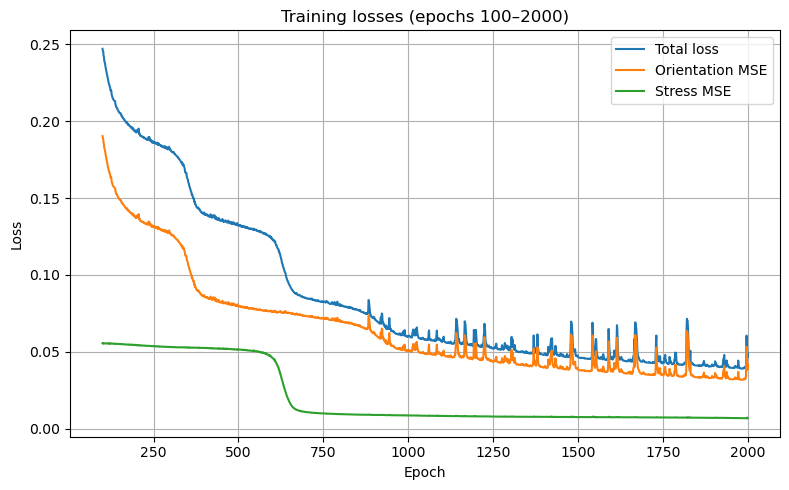

In [ ]:
import matplotlib.pyplot as plt

# epochs = range(1, num_epochs + 1)
start_epoch = 100
end_epoch = 2000

epochs = range(start_epoch, end_epoch)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_history["total"][start_epoch:end_epoch], label="Total loss")
plt.plot(epochs, train_history["ori"][start_epoch:end_epoch], label="Orientation MSE")
plt.plot(epochs, train_history["stress"][start_epoch:end_epoch], label="Stress MSE")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training losses (epochs {start_epoch}-{end_epoch})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [88]:
import torch
import torch.nn.functional as F

def r2_score_torch(y_true: torch.Tensor, y_pred: torch.Tensor, eps: float = 1e-12) -> float:
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return r2.item()

def evaluate_model(model, test_loader, device, quat_eps=1e-8, normalize_true=False):
    """
    normalize_true:
        False (default): assume labels are already unit quats
        True: also normalize q_true for extra safety
    """
    model.eval()

    all_q_pred, all_q_true = [], []
    all_s_pred, all_s_true = [], []

    with torch.no_grad():
        for data, y_true in test_loader:
            data = data.to(device)
            y_true = y_true.to(device)

            y_pred = model(data)

            all_q_pred.append(y_pred[..., 0:4])
            all_q_true.append(y_true[..., 0:4])
            all_s_pred.append(y_pred[..., 4:10])
            all_s_true.append(y_true[..., 4:10])

    q_pred = torch.cat(all_q_pred, dim=0)
    q_true = torch.cat(all_q_true, dim=0)
    s_pred = torch.cat(all_s_pred, dim=0)
    s_true = torch.cat(all_s_true, dim=0)

    # ---- normalize quaternion predictions (and optionally labels) ----
    q_pred = F.normalize(q_pred, p=2, dim=-1, eps=quat_eps)
    if normalize_true:
        q_true = F.normalize(q_true, p=2, dim=-1, eps=quat_eps)

    # ---- metrics ----
    theta = quaternion_misorientation_angle(q_pred, q_true)  # radians
    ori_mse = torch.mean(theta ** 2).item()

    stress_mse = F.mse_loss(s_pred, s_true).item()
    stress_r2  = r2_score_torch(s_true, s_pred)

    results = {
        "ori_mse": ori_mse,
        "stress_mse": stress_mse,
        "stress_r2": stress_r2,
        "theta_mean": theta.mean().item(),
        "theta_rmse": torch.sqrt(torch.mean(theta ** 2)).item(),
    }
    return results

In [70]:
import torch
import torch.nn.functional as F

def print_compare_path_grain_inc(
    model,
    dataset,
    path_idx: int,
    grain_idx: int,
    inc_idx: int,
    device,
    quat_eps=1e-8,
    voigt_names=None,
    average_over_grains=False,
):
    """
    dataset[path_idx] returns one strain path sample.

    Compare predicted vs true quaternion + stress for:
      - a specific grain (grain_idx) at increment (inc_idx), OR
      - the mean over all grains if average_over_grains=True.

    Shapes assumed:
      y_true, y_pred are either:
        [N_grains, T, F]  or [B, N_grains, T, F]
      with F >= 10 and first 10 are [q(4), stress(6)].
    """
    if voigt_names is None:
        voigt_names = ["s11", "s22", "s33", "s12", "s23", "s13"]

    model.eval()
    data, y_true = dataset[path_idx]
    data = data.to(device)
    y_true = y_true.to(device)

    with torch.no_grad():
        y_pred = model(data)

    # Ensure [B,N,T,F]
    if y_true.dim() == 3:  # [N,T,F]
        y_true = y_true.unsqueeze(0)
    if y_pred.dim() == 3:
        y_pred = y_pred.unsqueeze(0)

    # Slice increment
    q_true = y_true[:, :, inc_idx, 0:4]   # [B,N,4]
    q_pred = y_pred[:, :, inc_idx, 0:4]
    s_true = y_true[:, :, inc_idx, 4:10]  # [B,N,6]
    s_pred = y_pred[:, :, inc_idx, 4:10]

    if average_over_grains:
        # mean over grains (nodes)
        q_true_sel = q_true.mean(dim=1)   # [B,4]
        q_pred_sel = q_pred.mean(dim=1)
        s_true_sel = s_true.mean(dim=1)   # [B,6]
        s_pred_sel = s_pred.mean(dim=1)
        label = f"PATH {path_idx} | mean over all grains | inc {inc_idx}"
    else:
        # specific grain
        q_true_sel = q_true[:, grain_idx, :]  # [B,4]
        q_pred_sel = q_pred[:, grain_idx, :]
        s_true_sel = s_true[:, grain_idx, :]  # [B,6]
        s_pred_sel = s_pred[:, grain_idx, :]
        label = f"PATH {path_idx} | grain {grain_idx} | inc {inc_idx}"

    # Normalize quats for comparison/printing
    q_true_unit = F.normalize(q_true_sel, p=2, dim=-1, eps=quat_eps)
    q_pred_unit = F.normalize(q_pred_sel, p=2, dim=-1, eps=quat_eps)

    # Misorientation (your function)
    theta = quaternion_misorientation_angle(q_pred_unit, q_true_unit)  # [B] usually

    # torch-only deg conversion
    pi = torch.acos(torch.zeros(1, device=device)).item() * 2.0
    theta_deg = theta * (180.0 / pi)

    # Take first batch element for printing
    qT = q_true_unit[0].detach().cpu()
    qP = q_pred_unit[0].detach().cpu()
    sT = s_true_sel[0].detach().cpu()
    sP = s_pred_sel[0].detach().cpu()

    print(f"\n=== {label} ===")
    print("q_pred:", [float(f"{v:.6g}") for v in qP.tolist()])
    print("q_true:", [float(f"{v:.6g}") for v in qT.tolist()])
    print(f"misorientation (deg): mean={theta_deg.mean().item():.6f}, max={theta_deg.max().item():.6f}")

    print("\nStress (pred / true / err):")
    for k, name in enumerate(voigt_names):
        p = sP[k].item()
        t = sT[k].item()
        print(f"  {name:>3}:  pred={p: .6f}   true={t: .6f}   err={p-t: .6f}")

    stress_mse = F.mse_loss(sP, sT).item()
    stress_mae = torch.mean(torch.abs(sP - sT)).item()
    print(f"\nstress MSE={stress_mse:.6e}, stress MAE={stress_mae:.6e}")


In [102]:
checkpoint = torch.load("tgnn_simulation_5000e.pt", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

GNN_LMSC_Model(
  (lmsc): GNN_LMSC_cell(
    (qb): Quadratic_block(
      (modlist1): ModuleList(
        (0): Linear(in_features=70, out_features=70, bias=False)
        (1): Linear(in_features=70, out_features=70, bias=False)
        (2): Linear(in_features=70, out_features=70, bias=False)
        (3): Linear(in_features=70, out_features=125, bias=False)
      )
      (modlist2): ModuleList(
        (0): Linear(in_features=70, out_features=70, bias=False)
        (1): Linear(in_features=70, out_features=70, bias=False)
        (2): Linear(in_features=70, out_features=70, bias=False)
        (3): Linear(in_features=70, out_features=125, bias=False)
      )
    )
    (gconv1): GCN_block(
      (modlist): ModuleList(
        (0): GCNConv(70, 70)
      )
    )
    (gconv2): GCN_block(
      (modlist): ModuleList(
        (0): GCNConv(70, 70)
      )
    )
    (fc_alpha): Linear(in_features=125, out_features=64, bias=True)
    (fc_beta): Linear(in_features=125, out_features=64, bias=True)

In [104]:
results = evaluate_model(model, test_loader, device, normalize_true=False)
print(results)

{'ori_mse': 0.02732730284333229, 'stress_mse': 0.29804444313049316, 'stress_r2': -1.917952060699463, 'theta_mean': 0.10345420241355896, 'theta_rmse': 0.16530971229076385}


In [103]:
path_idx  = 0     # which strain path sample
grain_idx = 19    # which grain/node within that path (0..99)
inc_idx   = 12     # which increment (0..12)

print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, inc_idx, device)

# or compare mean over all grains:
# print_compare_path_grain_inc(model, test_loader.dataset, path_idx, grain_idx, inc_idx, device, average_over_grains=True)


=== PATH 0 | grain 19 | inc 12 ===
q_pred: [0.177336, 0.0267035, -0.58507, -0.790906]
q_true: [0.16221, -0.0075749, -0.554292, -0.816328]
misorientation (deg): mean=6.274250, max=6.274250

Stress (pred / true / err):
  s11:  pred=-0.552646   true= 0.738549   err=-1.291195
  s22:  pred= 0.046275   true= 0.406424   err=-0.360149
  s33:  pred=-0.833631   true= 0.636237   err=-1.469867
  s12:  pred= 0.090602   true=-0.346421   err= 0.437023
  s23:  pred= 0.045303   true=-0.027964   err= 0.073267
  s13:  pred= 0.124664   true= 0.516858   err=-0.392194

stress MSE=7.179293e-01, stress MAE=6.706160e-01


In [ ]:
b = 0         # batch index
g = 30       # grain index
t = 4         # increment


print("Prediction orientation: ", y_pred[b, g, t, 0:4])
print("Ground truth orientation: ", y_true[b, g, t, 0:4])
print('Original truth orientation: ', all_data[b+4, g, t, 0:4])
print('\n')

print("Prediction Cauchy stress: ", y_pred[b, g, t, 4:14])
print("Ground truth Cauchy stress: ", y_true[b, g, t, 4:14])
print("Original truth Cauchy stress: ", all_data[b+4, g, t, 22:31])
print('\n')

In [ ]:
import h5py

h5_data = h5py.File('demo_dataset_PN8_sq100.hdf5')
all_data = h5_data['data'][:]
# print(all_data.shape)

test_data = all_data[1]

# orig_ori = test_data[g, t, ]
print(test_data[g, t, ])

# test = all_data[:100, :, :]        # (100, 100, 15)
test = all_data[7, g, t, 3:9]        # (100, 100, 15)

# normalize stress channels only (3:9)
# test_stress = test[:, :, 3:9]
normalised_stress = normalize_stress(test, sigma_min, sigma_max)

# print(normalised_stress)
# print(sigma_min, sigma_max)

processed_data = create_data_object(test_data)
# print(processed_data.x)

[-390.3163  -110.51343   82.76505   -2.18077   44.80113  -60.64523]


In [ ]:
from torch import device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data, y_true = next(iter(loader))
data = data.to(device)
y_true = y_true.to(device)

y_pred = model(data)

print(y_pred.shape)
# print(data.x.shape)
print(y_true.shape)


torch.Size([2, 100, 100, 15])
torch.Size([2, 100, 100, 15])


In [ ]:
import pickle
import networkx as nx
import torch

with open("RVE24-n100_edge_feature.pickle", "rb") as f:
    edges = pickle.load(f)


def nx_to_edge_index(G):
    # Ensure nodes are labeled 0..N-1
    G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    # Get edge list
    edges = list(G.edges())

    # Make edges bidirectional
    row = []
    col = []
    for i, j in edges:
        row += [i, j]
        col += [j, i]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    return edge_index


torch.Size([2, 1504])
0 2
2 0
0 12
12 0
0 13
13 0
0 17
17 0
0 30
30 0
0 34
34 0
0 40
40 0
0 46
46 0
0 50
50 0
0 57
57 0
0 65
65 0
0 68
68 0
0 72
72 0
0 81
81 0
0 89
89 0
0 92
92 0
0 97
97 0
2 4
4 2
2 17
17 2
2 18
18 2
2 34
34 2
2 36
36 2
2 40
40 2
2 59
59 2
2 60
60 2
2 68
68 2
2 74
74 2
2 79
79 2
2 82
82 2
2 85
85 2
2 89
89 2
2 98
98 2
12 13
13 12
12 15
15 12
12 30
30 12
12 31
31 12
12 37
37 12
12 38
38 12
12 57
57 12
12 61
61 12
12 72
72 12
12 80
80 12
12 91
91 12
12 95
95 12
12 97
97 12
13 5
5 13
13 37
37 13
13 38
38 13
13 46
46 13
13 57
57 13
13 58
58 13
13 68
68 13
13 81
81 13
13 85
85 13
13 92
92 13
13 97
97 13
13 99
99 13
17 18
18 17
17 24
24 17
17 34
34 17
17 48
48 17
17 50
50 17
17 65
65 17
17 68
68 17
17 74
74 17
17 82
82 17
30 11
11 30
30 26
26 30
30 31
31 30
30 39
39 30
30 50
50 30
30 57
57 30
30 61
61 30
30 72
72 30
30 76
76 30
30 78
78 30
30 91
91 30
30 98
98 30
34 4
4 34
34 32
32 34
34 37
37 34
34 40
40 34
34 50
50 34
34 56
56 34
34 59
59 34
34 60
60 34
34 61
61 34
34 72


In [ ]:
# data_obj = create_data_object(data[0])

# print(data_obj.x.shape)

# for batch in loader:
#     print("x:", batch.x.shape)
#     print("edge_index:", batch.edge_index.shape)
#     print("init_ori:", batch.init_ori.shape)
#     print("batch vector:", batch.batch.shape)
#     break

print(path0[0, :5, 0:3])
print(np.deg2rad(path0[0, :5, 0:3]))              # convert to radians

[[228.0067   18.6711   15.5926 ]
 [227.94653  18.63262  15.63924]
 [227.88055  18.59222  15.68936]
 [227.80481  18.55232  15.74941]
 [227.7251   18.51262  15.81334]]
[[3.9794676  0.32587218 0.2721422 ]
 [3.9784174  0.32520056 0.27295622]
 [3.9772658  0.32449546 0.27383098]
 [3.975944   0.32379907 0.27487904]
 [3.9745526  0.3231062  0.27599484]]


In [ ]:
import numpy as np

# for path in data:
#     print(path[13, 0, 9:15])

#     # print(len(path[0, :, 9:15]))

# print(data[0, :, 0, 9:15])

path0 = data[0]

print(path0[:100, 0, 9:15])
# print(np.diff(path0[100, :, 9:15][:3], axis=0))


test = [[1, 1, 1], [2, 2, 2], [3, 3, 3], [4, 4, 4]]
# print(np.diff(test))

arr = np.array([[1, 2],
                [2, 3]])

# print(arr.shape)  # (2, 2)

# print(np.diff(arr, axis=0))

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0.

In [ ]:
edge_index = torch.tensor([
    [i for i in range(99) for _ in (0,)],
    [i+1 for i in range(99)]
], dtype=torch.long)

print(edge_index)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
         72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
         90, 91, 92, 93, 94, 95, 96, 97, 98],
        [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
         37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54,
         55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
         73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90,
         91, 92, 93, 94, 95, 96, 97, 98, 99]])
